# Heart Disease UCI Dataset — Exploratory Data Analysis

This notebook reuses the same cleaning logic as
`src/heart_disease/data.py` (installed as the `heart_disease` package) so the EDA here is
guaranteed to match what the training pipeline actually sees.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from heart_disease.data import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    TARGET,
    get_clean_dataset,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

## 1. Load & clean the dataset

`get_clean_dataset()` downloads the raw CSV from the UCI repository (if not
already present), parses `?` as missing, mode-imputes the handful of missing `ca`/`thal`
values, and binarizes the target (`num > 0 -> 1`).

In [2]:
df = get_clean_dataset()
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    float64
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 33.3 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 2. Missing value analysis

Should be all zeros — `ca` and `thal` had a small number of `?` values in the raw file,
resolved by mode imputation in `clean_data()`.

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


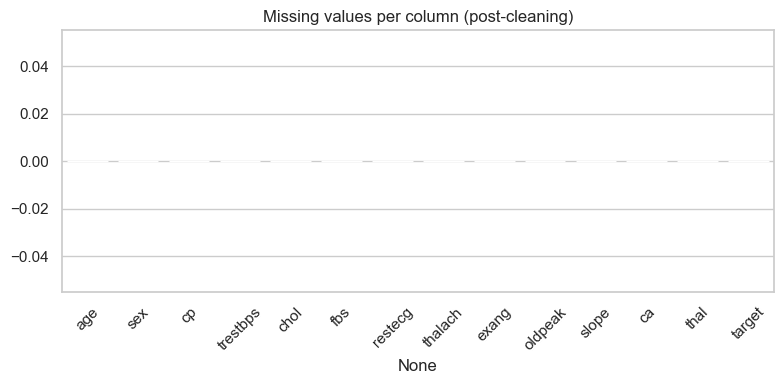

In [5]:
missing = df.isna().sum()
print(missing)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing.index, y=missing.values, ax=ax)
ax.set_title("Missing values per column (post-cleaning)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Class balance

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


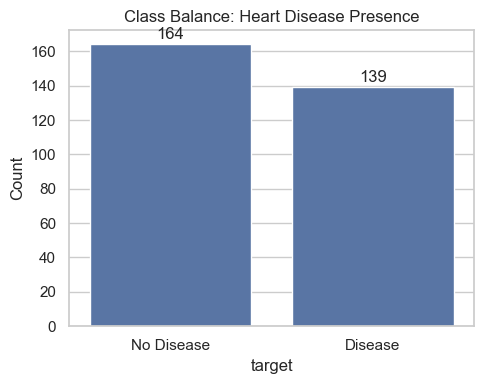

In [6]:
print(df[TARGET].value_counts(normalize=True))

fig, ax = plt.subplots(figsize=(5, 4))
counts = df[TARGET].value_counts().sort_index()
sns.barplot(x=counts.index.map({0: "No Disease", 1: "Disease"}), y=counts.values, ax=ax)
ax.set_title("Class Balance: Heart Disease Presence")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha="center")
plt.tight_layout()
plt.show()

## 4. Feature distributions (numeric features by class)

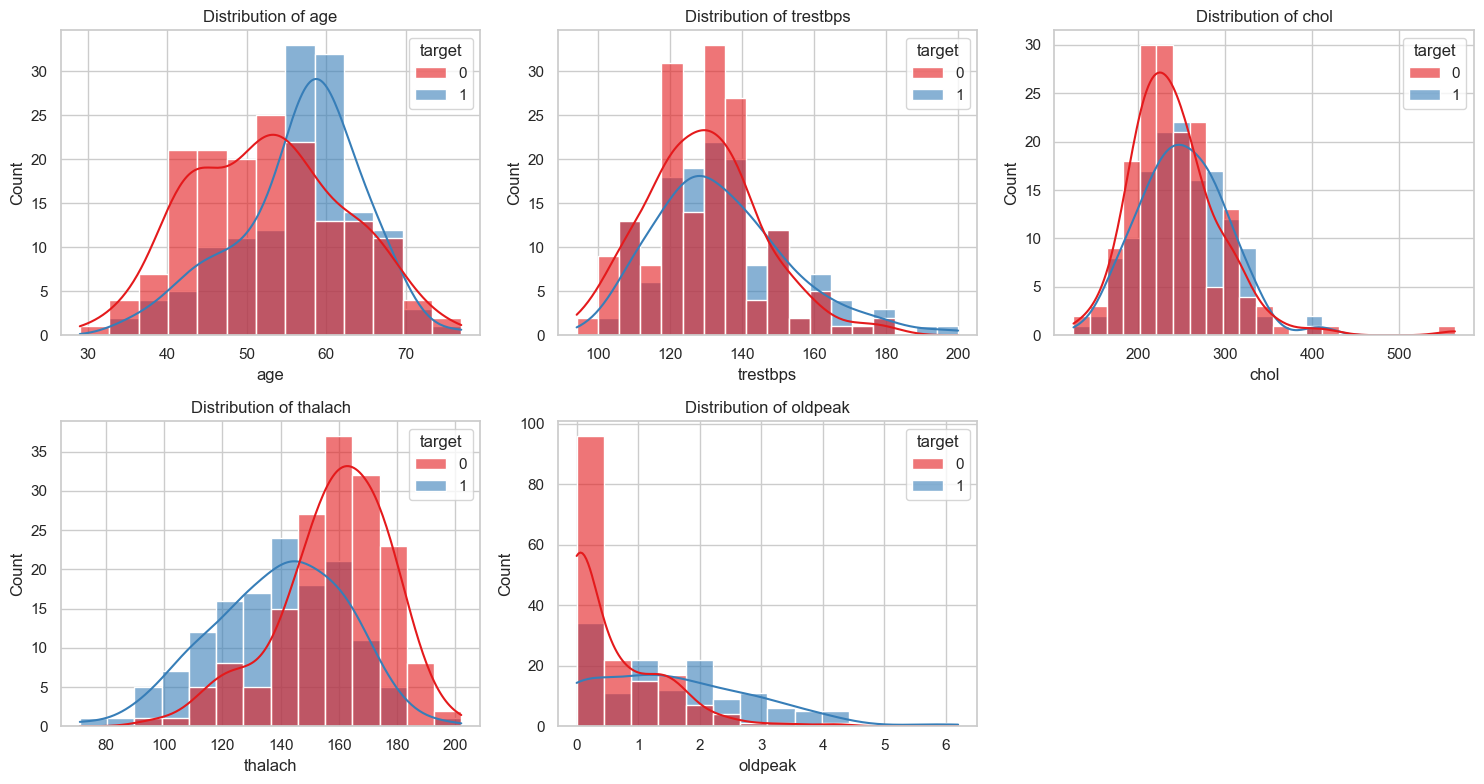

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    sns.histplot(data=df, x=col, hue=TARGET, kde=True, ax=ax, palette="Set1", alpha=0.6)
    ax.set_title(f"Distribution of {col}")
for ax in axes.flat[len(NUMERIC_FEATURES):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Correlation heatmap

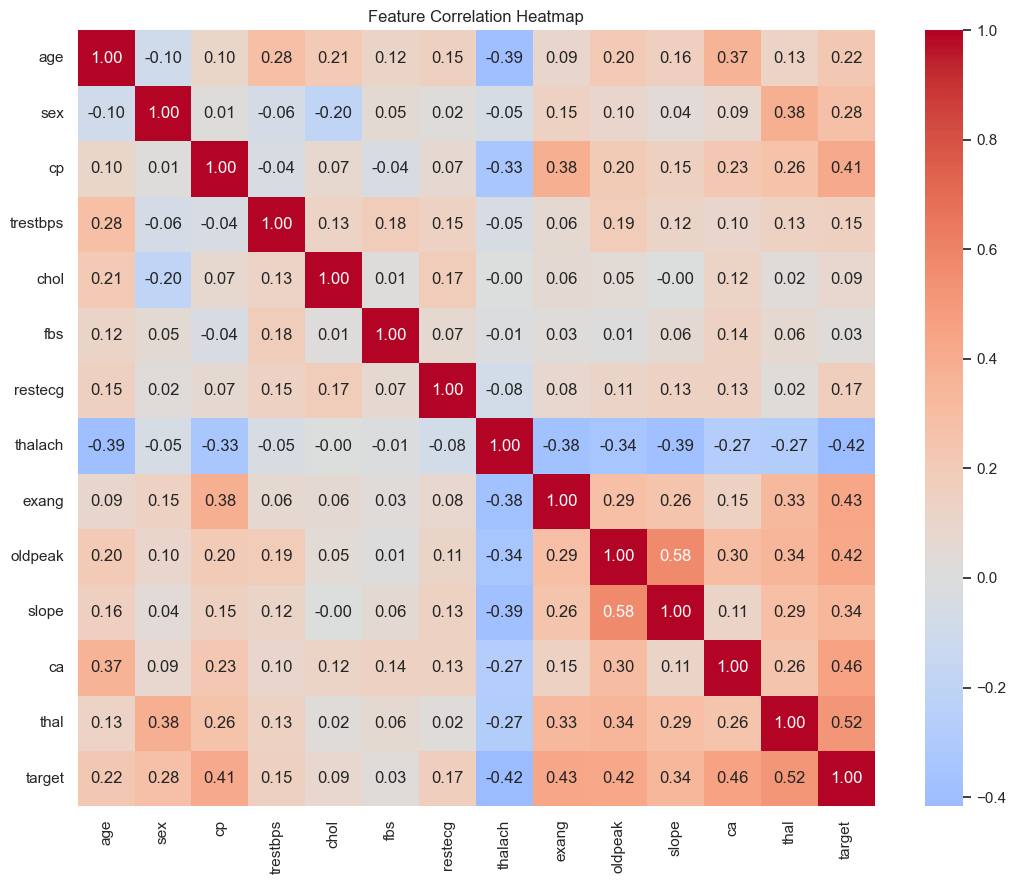

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 6. Feature relationships with the target

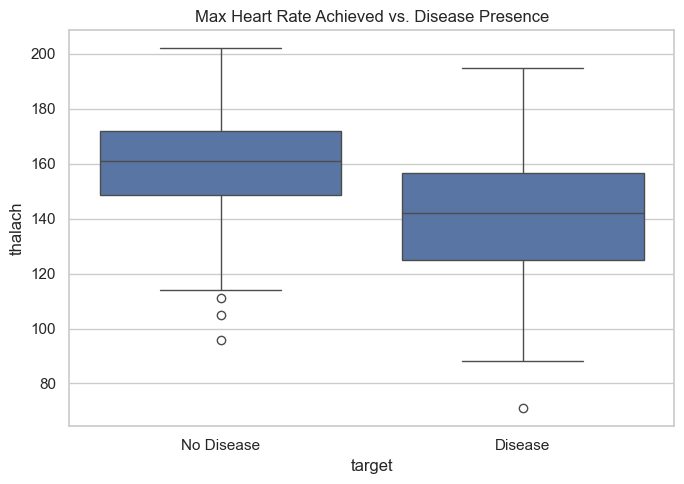

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x=TARGET, y="thalach", ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Disease", "Disease"])
ax.set_title("Max Heart Rate Achieved vs. Disease Presence")
plt.tight_layout()
plt.show()

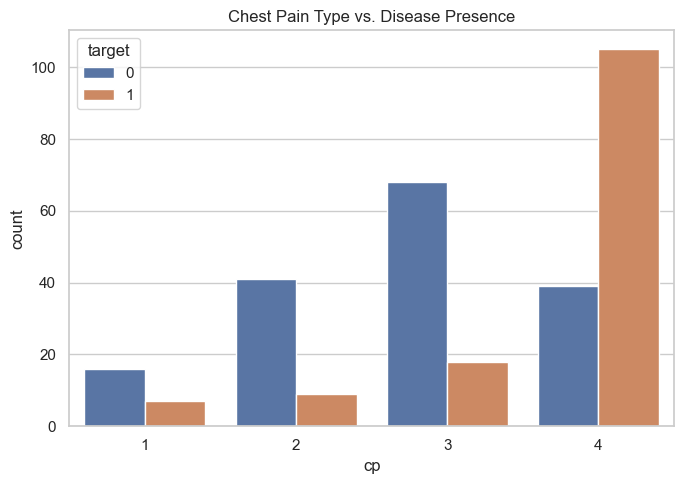

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x="cp", hue=TARGET, ax=ax)
ax.set_title("Chest Pain Type vs. Disease Presence")
plt.tight_layout()
plt.show()

## 7. Summary of findings

- Dataset is reasonably balanced (~54% no disease vs. ~46% disease presence) — no
  resampling required.
- No missing values remain after cleaning (`ca`/`thal` mode-imputed).
- `thal`, `ca`, `exang`, `oldpeak`, and `cp` show the strongest correlation with the target.
- `thalach` (max heart rate achieved) is negatively correlated with disease presence —
  patients without disease tend to reach a higher max heart rate during exercise testing.
- These signals carry through consistently to the feature importance / coefficients seen in
  the trained models in `notebooks/` training pipeline (`heart_disease.train`).